# Using and evaluating LLMs for social sciences

### STaRT 2026, Rice University

Each part shows the **prompt**, the **raw answers**, and the **analysis**. Run the cells in order (▶ or Shift+Enter). To make it yours, change the text in CAPITALS.

First move: **File → Save a copy in Drive**.

## 0 · Setup

You need an Anthropic API key. In Colab, add it in the Secrets pane (🔑 on the left) under the name `ANTHROPIC_API_KEY` and switch on notebook access. Otherwise the cell asks you to type it (hidden).

In [ ]:
import subprocess, sys
try:
    import anthropic
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "anthropic"], check=True)
    import anthropic

import os, re, math, statistics
from collections import Counter

key = os.environ.get("ANTHROPIC_API_KEY")
if not key:
    try:
        from google.colab import userdata
        key = userdata.get("ANTHROPIC_API_KEY")
    except Exception:
        pass
if not key:
    from getpass import getpass
    key = getpass("Anthropic API key: ")

MODEL = "claude-sonnet-5-5"   # the instrument; report it in your methods section
client = anthropic.Anthropic(api_key=key, max_retries=5)
print("ready:", MODEL)

ready: claude-sonnet-5-5


### The instrument

`ask(prompt)` sends one question to the model and returns the answer as text. Every call is independent, so asking 10 times gives 10 fresh answers. `system` is the standing instruction (the interviewer script); `effort="low"` keeps the model from deliberating, since survey answers are meant to be quick; a refusal comes back as `[REFUSAL]`.

In [ ]:
SYSTEM = "You are answering a social-science survey. Answer the question as asked."

def ask(prompt, system=SYSTEM, max_tokens=1000, effort="low"):
    response = client.messages.create(
        model=MODEL, max_tokens=max_tokens, system=system,
        messages=[{"role": "user", "content": prompt}],
        output_config={"effort": effort},
    )
    if response.stop_reason == "refusal":
        return "[REFUSAL]"
    return "".join(b.text for b in response.content if b.type == "text").strip()

def first_number(text, lo, hi):
    '''The first integer within the scale found in the answer, or None.'''
    for m in re.findall(r"-?\d+", text):
        if lo <= int(m) <= hi:
            return int(m)
    return None

print(ask("Say hello in five words."))

Hello, it's nice to meet you.


### The toolkit

Helper functions. Run this cell once; you do not need to read it. `run_many` asks n times, `run_population` asks once for 100 imagined people, `compare` and `plot` summarize the answers.

In [ ]:
def run_many(question, n, scale, system=SYSTEM, show=True):
    '''Ask n times, one answer each. Prints prompt, raw answers, tally. Returns parsed numbers.'''
    lo, hi = scale
    prompt = question + "\nAnswer with a single number."
    answers = [ask(prompt, system=system) for _ in range(n)]
    numbers = [first_number(a, lo, hi) for a in answers]
    if show:
        print("PROMPT\n" + prompt + "\n\nRAW ANSWERS")
        for a, v in zip(answers, numbers):
            short = a if len(a) <= 90 else a[:90] + "…"
            print(f"  {short!r}  ->  {v}")
        valid = [v for v in numbers if v is not None]
        print("\nTALLY", dict(sorted(Counter(valid).items())), f"| failed to parse: {numbers.count(None)}")
        if valid:
            print(f"mean {statistics.mean(valid):.2f}   spread (sd) {statistics.pstdev(valid):.2f}")
    return numbers

def run_population(question, scale, population, show=True):
    '''Ask once for 100 imagined people. Prints prompt and tally. Returns the 100 numbers.'''
    lo, hi = scale
    prompt = (question + f"\nImagine 100 different {population} answering this question. "
              f"Write exactly 100 numbers ({lo}-{hi}), one per person, as a Python list of integers and nothing else.")
    answer = ask(prompt, system="You are helping a social scientist simulate survey responses.", max_tokens=1500)
    numbers = [int(x) for x in re.findall(r"\b\d+\b", answer) if lo <= int(x) <= hi]
    if show:
        print("PROMPT\n" + prompt + "\n\nRAW ANSWER (first 120 characters)\n  " + answer[:120].replace("\n", " ") + "…")
        print(f"\nTALLY ({len(numbers)} numbers)", dict(sorted(Counter(numbers).items())))
        if numbers:
            print(f"mean {statistics.mean(numbers):.2f}   spread (sd) {statistics.pstdev(numbers):.2f}")
    return numbers

def distribution(numbers, scale):
    lo, hi = scale
    valid = [v for v in numbers if v is not None]
    return [valid.count(k) / len(valid) for k in range(lo, hi + 1)] if valid else None

def wasserstein(p, q):
    cp = cq = total = 0.0
    for a, b in zip(p, q):
        cp += a; cq += b; total += abs(cp - cq)
    return total

def entropy(p):
    return max(0.0, -sum(x * math.log2(x) for x in p if x > 0))

def compare(results, scale, title=""):
    lo, hi = scale
    names = list(results)
    dists = {n: distribution(results[n], scale) for n in names}
    means = {n: statistics.mean([v for v in results[n] if v is not None]) for n in names}
    print(title)
    print(f"{'':14s}" + "".join(f"{k:>6d}" for k in range(lo, hi + 1)) + "    mean  entropy")
    for n in names:
        print(f"{n:14s}" + "".join(f"{x:6.2f}" for x in dists[n]) + f"  {means[n]:6.2f}  {entropy(dists[n]):5.2f}")
    a, b = names[:2]
    print(f"{a} vs {b}: mean difference {means[a] - means[b]:+.2f}, "
          f"Wasserstein {wasserstein(dists[a], dists[b]):.2f} scale points\n")
    return dists

import matplotlib.pyplot as plt

def plot(dists, scale, title=""):
    lo, hi = scale
    xs = list(range(lo, hi + 1))
    colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
    w = 0.8 / len(dists)
    fig, ax = plt.subplots(figsize=(7, 3))
    for i, (name, p) in enumerate(dists.items()):
        ax.bar([x + (i - (len(dists) - 1) / 2) * w for x in xs], p, width=w * 0.9,
               color=colors[i], label=name, linewidth=0)
    ax.set_xticks(xs); ax.set_ylim(0, 1); ax.set_xlabel("answer"); ax.set_ylabel("share")
    ax.set_title(title, loc="left", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", color="#e6e6e3"); ax.set_axisbelow(True)
    ax.legend(frameon=False); plt.show()

print("toolkit ready")

toolkit ready


## 1 · Change one thing

Two prompts that differ in **exactly one thing**. Here the one thing is a single word, and the finding is decades old: Americans say the government spends too much on *welfare* and too little on *assistance to the poor* (Rasinski 1989). Does the model reproduce it?

Each condition is asked two ways: **way 1** asks the model `N` times, one answer each (the model's own answer distribution); **way 2** asks once for 100 imagined people (the model's belief about a population). They are different objects, and a paper must say which one it measured.

To change the experiment, edit `CONDITIONS`: wording, option order, a name, a persona, the language of the prompt. If something breaks, put the original values back and re-run.

In [ ]:
# settings for part 1
POPULATION = "adults in the United States"
CONDITIONS = {
    "welfare": '''Do you think the government spends too little, about right, or too much on welfare?
1 = far too little, 3 = about right, 5 = far too much.''',

    "assistance": '''Do you think the government spends too little, about right, or too much on assistance to the poor?
1 = far too little, 3 = about right, 5 = far too much.''',
}
SCALE = (1, 5)
N = 10

In [ ]:
single = {}
population = {}
for name, question in CONDITIONS.items():
    print(f"===== condition: {name} | way 1: ask {N} times =====")
    single[name] = run_many(question, N, SCALE)
    print(f"\n===== condition: {name} | way 2: 100 imagined {POPULATION} =====")
    population[name] = run_population(question, SCALE, POPULATION)
    print()

===== condition: welfare | way 1: ask 10 times =====


PROMPT
Do you think the government spends too little, about right, or too much on welfare?
1 = far too little, 3 = about right, 5 = far too much.
Answer with a single number.

RAW ANSWERS
  '3'  ->  3
  '**3**'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3

TALLY {3: 10} | failed to parse: 0
mean 3.00   spread (sd) 0.00

===== condition: welfare | way 2: 100 imagined adults in the United States =====


PROMPT
Do you think the government spends too little, about right, or too much on welfare?
1 = far too little, 3 = about right, 5 = far too much.
Imagine 100 different adults in the United States answering this question. Write exactly 100 numbers (1-5), one per person, as a Python list of integers and nothing else.

RAW ANSWER (first 120 characters)
  [1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,4…

TALLY (98 numbers) {1: 10, 2: 19, 3: 29, 4: 20, 5: 20}
mean 3.21   spread (sd) 1.26

===== condition: assistance | way 1: ask 10 times =====


PROMPT
Do you think the government spends too little, about right, or too much on assistance to the poor?
1 = far too little, 3 = about right, 5 = far too much.
Answer with a single number.

RAW ANSWERS
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2
  '2'  ->  2

TALLY {2: 10} | failed to parse: 0
mean 2.00   spread (sd) 0.00

===== condition: assistance | way 2: 100 imagined adults in the United States =====


PROMPT
Do you think the government spends too little, about right, or too much on assistance to the poor?
1 = far too little, 3 = about right, 5 = far too much.
Imagine 100 different adults in the United States answering this question. Write exactly 100 numbers (1-5), one per person, as a Python list of integers and nothing else.

RAW ANSWER (first 120 characters)
  [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3…

TALLY (100 numbers) {1: 15, 2: 25, 3: 27, 4: 20, 5: 13}
mean 2.91   spread (sd) 1.25



### Compare the conditions

**Wasserstein distance** is how far answers would have to move, in scale points, to turn one distribution into the other. **Entropy** is how spread out one condition's answers are (0 = the same answer every time).

WAY 1: the model's own answers
                   1     2     3     4     5    mean  entropy
welfare         0.00  0.00  1.00  0.00  0.00    3.00   0.00
assistance      0.00  1.00  0.00  0.00  0.00    2.00   0.00
welfare vs assistance: mean difference +1.00, Wasserstein 1.00 scale points

WAY 2: 100 imagined adults in the United States
                   1     2     3     4     5    mean  entropy
welfare         0.10  0.19  0.30  0.20  0.20    3.21   2.25
assistance      0.15  0.25  0.27  0.20  0.13    2.91   2.27
welfare vs assistance: mean difference +0.30, Wasserstein 0.30 scale points



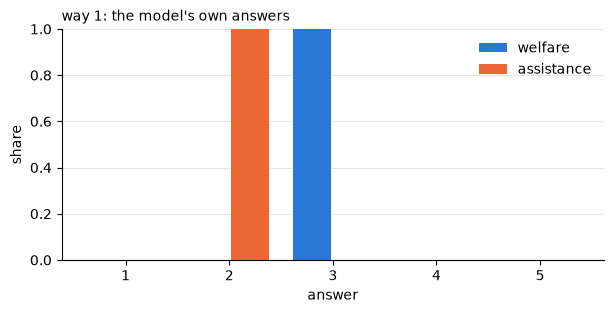

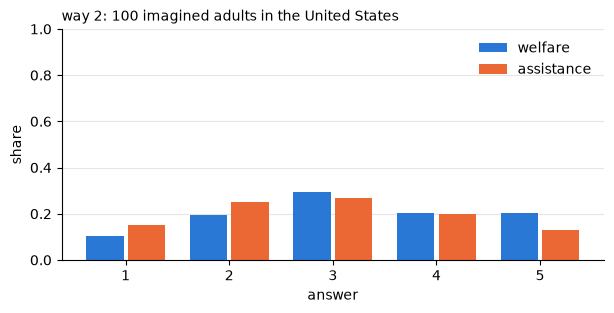

In [ ]:
dists_single = compare(single, SCALE, "WAY 1: the model's own answers")
dists_population = compare(population, SCALE, "WAY 2: 100 imagined " + POPULATION)
plot(dists_single, SCALE, "way 1: the model's own answers")
plot(dists_population, SCALE, "way 2: 100 imagined " + POPULATION)

**Read the raw answers, not just the table.** Did one condition answer with a bare number and the other with a paragraph of caveats first? That difference is invisible in the mean.

Activity 1, just below, is where you try your own conditions.

### Activity 1: modify the prompt

Now change one thing yourself. Edit `MY_CONDITIONS` below: a different question, a paraphrase, the same options in reverse order, a persona in front of the question, or the same sentence in two varieties of English. Keep the scale the same across conditions, then run the two cells below it. The demo cells above stay untouched, so you can always go back to them.

In [ ]:
# activity 1 settings: replace these two conditions with your own
MY_CONDITIONS = {
    "as written": '''Do you think the government spends too little, about right, or too much on welfare?
1 = far too little, 3 = about right, 5 = far too much.''',

    "reversed scale": '''Do you think the government spends too little, about right, or too much on welfare?
1 = far too much, 3 = about right, 5 = far too little.''',
}
MY_SCALE = (1, 5)
MY_N = 10
MY_POPULATION = "adults in the United States"

In [ ]:
my_single = {}
my_population = {}
for name, question in MY_CONDITIONS.items():
    print(f"===== condition: {name} | way 1: ask {MY_N} times =====")
    my_single[name] = run_many(question, MY_N, MY_SCALE)
    print(f"\n===== condition: {name} | way 2: 100 imagined {MY_POPULATION} =====")
    my_population[name] = run_population(question, MY_SCALE, MY_POPULATION)
    print()

===== condition: as written | way 1: ask 10 times =====


PROMPT
Do you think the government spends too little, about right, or too much on welfare?
1 = far too little, 3 = about right, 5 = far too much.
Answer with a single number.

RAW ANSWERS
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3

TALLY {3: 10} | failed to parse: 0
mean 3.00   spread (sd) 0.00

===== condition: as written | way 2: 100 imagined adults in the United States =====


PROMPT
Do you think the government spends too little, about right, or too much on welfare?
1 = far too little, 3 = about right, 5 = far too much.
Imagine 100 different adults in the United States answering this question. Write exactly 100 numbers (1-5), one per person, as a Python list of integers and nothing else.

RAW ANSWER (first 120 characters)
  [1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4…

TALLY (102 numbers) {1: 10, 2: 19, 3: 30, 4: 23, 5: 20}
mean 3.24   spread (sd) 1.24

===== condition: reversed scale | way 1: ask 10 times =====


PROMPT
Do you think the government spends too little, about right, or too much on welfare?
1 = far too much, 3 = about right, 5 = far too little.
Answer with a single number.

RAW ANSWERS
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3
  '3'  ->  3

TALLY {3: 10} | failed to parse: 0
mean 3.00   spread (sd) 0.00

===== condition: reversed scale | way 2: 100 imagined adults in the United States =====


PROMPT
Do you think the government spends too little, about right, or too much on welfare?
1 = far too much, 3 = about right, 5 = far too little.
Imagine 100 different adults in the United States answering this question. Write exactly 100 numbers (1-5), one per person, as a Python list of integers and nothing else.

RAW ANSWER (first 120 characters)
  [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3…

TALLY (98 numbers) {1: 15, 2: 22, 3: 30, 4: 19, 5: 12}
mean 2.91   spread (sd) 1.23



WAY 1: the model's own answers
                   1     2     3     4     5    mean  entropy
as written      0.00  0.00  1.00  0.00  0.00    3.00   0.00
reversed scale  0.00  0.00  1.00  0.00  0.00    3.00   0.00
as written vs reversed scale: mean difference +0.00, Wasserstein 0.00 scale points

WAY 2: 100 imagined adults in the United States
                   1     2     3     4     5    mean  entropy
as written      0.10  0.19  0.29  0.23  0.20    3.24   2.24
reversed scale  0.15  0.22  0.31  0.19  0.12    2.91   2.25
as written vs reversed scale: mean difference +0.33, Wasserstein 0.33 scale points



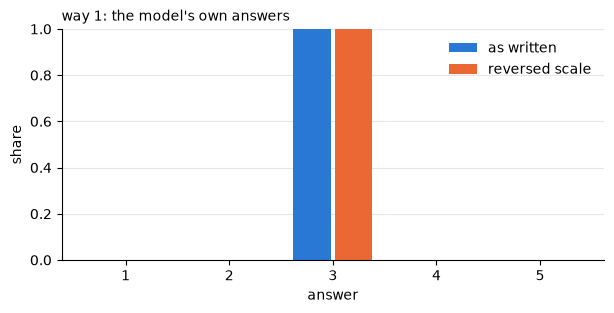

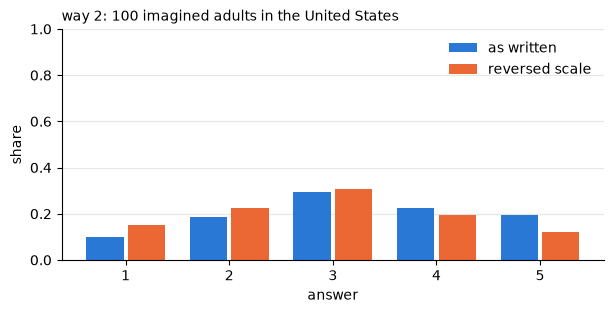

In [ ]:
my_dists_single = compare(my_single, MY_SCALE, "WAY 1: the model's own answers")
my_dists_population = compare(my_population, MY_SCALE, "WAY 2: 100 imagined " + MY_POPULATION)
plot(my_dists_single, MY_SCALE, "way 1: the model's own answers")
plot(my_dists_population, MY_SCALE, "way 2: 100 imagined " + MY_POPULATION)

**What moved?** Write one sentence: which condition changed the answers, in which direction, and whether the raw answers looked different (a bare number vs a paragraph of caveats). Keep it for the debrief.

## 2 · Open-ended answers, and the model as coder

One open question, two personas, `N_OPEN` answers each. Then the model codes every answer with a small codebook, so it is both the respondent and the coder. Edit `OPEN_QUESTION`, `PERSONAS`, and `CODEBOOK`. This part does not use anything from part 1.

In [ ]:
# settings for part 2
OPEN_QUESTION = "In one sentence: what is the most important problem facing the country today?"

PERSONAS = {
    "retired teacher, Ohio":   "You are a 62-year-old retired teacher living in a small town in Ohio. Answer in your own voice.",
    "grad student, Houston":   "You are a 24-year-old graduate student living in Houston, Texas. Answer in your own voice.",
}

CODEBOOK = {
    "ECON":  "economy, prices, cost of living, jobs, taxes, housing",
    "POLIT": "the political system, polarization, democracy, corruption, politicians",
    "SOC":   "social policy: health care, education, immigration, inequality, crime",
    "ENV":   "environment and climate",
    "OTHER": "anything else, including don't know and refusals",
}
N_OPEN = 6

In [ ]:
open_answers = {}
for name, persona in PERSONAS.items():
    print(f"===== {name} =====")
    open_answers[name] = [ask(OPEN_QUESTION, system=persona, max_tokens=2000) for _ in range(N_OPEN)]
    for a in open_answers[name]:
        print("  -", a)
    print()

===== retired teacher, Ohio =====


  - Honestly, I think it's that we've stopped being able to talk with our neighbors across political lines, because when people see each other as enemies instead of fellow citizens, nothing else, from schools to the economy, gets fixed.
  - Honestly, I think it's that we've stopped listening to each other: neighbors who used to disagree over coffee now treat each other like enemies, and until we fix that, we won't solve much of anything else.
  - Honestly, I think it's that we've lost the ability to disagree with each other like neighbors, because when folks can't sit down at the same table and listen, nothing else, whether it's the economy, schools, or health care, ever gets fixed.
  - Honestly, I think it's that we've stopped being able to talk to our neighbors across political lines, because when we can't listen to each other, we can't solve any of the other problems, whether that's the cost of living, schools, or health care.
  - Honestly, I think it's that we've stopped being able

  - Honestly, it's the cost of living: rent, groceries, health care, and student loans keep climbing faster than paychecks, so it feels like people my age are working harder just to avoid falling behind, let alone get ahead.
  - Honestly, it's the cost of living: between rent, groceries, health care, and student loans, it feels like even people with good jobs and degrees are struggling to build a stable life, and that's especially true for people my age trying to get started.
  - Honestly, it's the cost of living: rent, groceries, and healthcare keep climbing faster than paychecks, so it feels like people my age are working harder just to avoid falling behind, let alone buy a home or start a family.
  - Honestly, I think it's that we've become so politically polarized that we can't agree on basic facts or work together on anything, which makes it nearly impossible to make real progress on issues like the cost of living, healthcare, and housing that actually affect people's daily lives.

In [ ]:
def code_answer(answer):
    '''The model as coder: the codebook goes in the prompt, one code comes out.'''
    book = "\n".join(f"{k}: {v}" for k, v in CODEBOOK.items())
    prompt = (f"Codebook:\n{book}\n\nRule: assign exactly one code, for the first topic mentioned. "
              f"Use no outside knowledge.\n\nResponse: \"{answer}\"\n\nAnswer with the code only.")
    out = ask(prompt, system="You are a trained content-analysis coder.").upper()
    return next((k for k in CODEBOOK if k in out), "OTHER")

codes = {}
for name, answers in open_answers.items():
    codes[name] = [code_answer(a) for a in answers]
    print(f"===== {name} =====")
    for c, a in zip(codes[name], answers):
        print(f"  {c:6s} {a[:100]}{'…' if len(a) > 100 else ''}")
    print("  distribution:", dict(Counter(codes[name])), "\n")

===== retired teacher, Ohio =====
  POLIT  Honestly, I think it's that we've stopped being able to talk with our neighbors across political lin…
  POLIT  Honestly, I think it's that we've stopped listening to each other: neighbors who used to disagree ov…
  ECON   Honestly, I think it's that we've lost the ability to disagree with each other like neighbors, becau…
  POLIT  Honestly, I think it's that we've stopped being able to talk to our neighbors across political lines…
  POLIT  Honestly, I think it's that we've stopped being able to talk to our neighbors across political lines…
  POLIT  Honestly, I think it's that we've stopped being able to talk to our neighbors who see things differe…
  distribution: {'POLIT': 5, 'ECON': 1} 



===== grad student, Houston =====
  ECON   Honestly, it's the cost of living: rent, groceries, health care, and student loans keep climbing fas…
  ECON   Honestly, it's the cost of living: between rent, groceries, health care, and student loans, it feels…
  ECON   Honestly, it's the cost of living: rent, groceries, and healthcare keep climbing faster than paychec…
  POLIT  Honestly, I think it's that we've become so politically polarized that we can't agree on basic facts…
  POLIT  Honestly, I think it's that we've lost the ability to agree on a shared set of facts, which makes it…
  ECON   Honestly, it's the cost of living: between rent, groceries, health care, and student loans, it feels…
  distribution: {'ECON': 4, 'POLIT': 2} 



**Check the coder.** Would you have given the same codes? Where you disagree, is it the codebook or the coder? In a real study you code a sample by hand and report agreement (Cohen's κ) before letting the model code the rest. And note there is no human baseline here yet: two personas compared with each other tell you about the model, not about Ohio or Houston.

## 3 · Activity 2: design and run your own study

Fill in the design sheet from the slides first. Then copy the cells of part 1 (closed answers, two or more conditions) or part 2 (open answers, coded) below and change the CAPITALS. After you run, write four sentences for a methods section: model and date, the exact prompts, `N` per condition, and the metric.

In [ ]:
# activity 2: your study here